<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [1]:
# This will remove all user-defined variables from the workspace
%reset -f

In [2]:
# Import any packages
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
import holidays

# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

# Joint forecastdemand_nsw files into a single file. 
!cat data/NSW/forecastdemand_nsw.csv.zip.part* > data/NSW/forecastdemand_nsw.csv.zip

# Unzip the data files into the data folder
!unzip -o data/NSW/forecastdemand_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/temperature_nsw.csv.zip -d data/NSW
!unzip -o data/NSW/totaldemand_nsw.csv.zip -d data/NSW

# Remove forecastdemand_nsw.csv.zip
!rm data/NSW/forecastdemand_nsw.csv.zip

# the forecastdemand_nsw.csv file
df_forecast = pd.read_csv('data/NSW/forecastdemand_nsw.csv')

# the temperature_nsw.csv file
df_temperature = pd.read_csv('data/NSW/temperature_nsw.csv')

#  the totaldemand_nsw.csv file
df_totaldemand = pd.read_csv('data/NSW/totaldemand_nsw.csv')

# delete the unzipped files to save space
!rm data/NSW/forecastdemand_nsw.csv
!rm data/NSW/temperature_nsw.csv
!rm data/NSW/totaldemand_nsw.csv

# Convert all to pandas datetime and normalize to day-level
# Convert 'DATETIME' columns to datetime format (auto-infer format)
df_forecast['DATETIME'] = pd.to_datetime(df_forecast['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_temperature['DATETIME'] = pd.to_datetime(df_temperature['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
df_totaldemand['DATETIME'] = pd.to_datetime(df_totaldemand['DATETIME'], format='mixed', dayfirst=True, errors='coerce')
# Group forecast by DATETIME and average
df_forecast_avg = df_forecast.groupby('DATETIME', as_index=False)['FORECASTDEMAND'].mean()

# Merge all DataFrames on 'DATETIME'
df_merged = df_forecast_avg.merge(df_totaldemand[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='left') \
                           .merge(df_temperature[['DATETIME', 'TEMPERATURE']], on='DATETIME', how='left')

# Resample by day and calculate min, max, and mean for TEMPERATURE
# Set 'DATETIME' as index before resampling
df_merged = df_merged.set_index('DATETIME')

df_daily = df_merged.resample('D').agg({
    'TEMPERATURE': ['min', 'max', 'mean'],
    'FORECASTDEMAND': 'mean',
    'TOTALDEMAND': 'mean'
})

Archive:  data/NSW/forecastdemand_nsw.csv.zip
  inflating: data/NSW/forecastdemand_nsw.csv  

Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/temperature_nsw.csv.zip
  inflating: data/NSW/temperature_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  
Archive:  data/NSW/totaldemand_nsw.csv.zip
  inflating: data/NSW/totaldemand_nsw.csv  


In [3]:

# Create binary features for extreme temperature events
df_daily['IS_EXTREME_HOT'] = (df_daily['TEMPERATURE']['max'] > 35).astype(bool)
df_daily['IS_EXTREME_COLD'] = (df_daily['TEMPERATURE']['min'] < 5).astype(bool)
df_daily['IS_REGULAR'] = ((df_daily['TEMPERATURE']['max'] <= 35) & (df_daily['TEMPERATURE']['min'] >= 5))

# Base performance
base_mse = mean_squared_error(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])
base_r2 = r2_score(df_daily['TOTALDEMAND']['mean'], df_daily['FORECASTDEMAND']['mean'])

hot_mask = df_daily['IS_EXTREME_HOT']
cold_mask = df_daily['IS_EXTREME_COLD']
regular_mask = df_daily['IS_REGULAR']

masks = {
    'Extreme Hot Days': hot_mask,
    'Extreme Cold Days': cold_mask,
    'Regular Days': regular_mask
}

print('-----------------------------------')

print('Number of Extreme Hot Days:', hot_mask.sum(), f"({hot_mask.sum()/len(df_daily)*100:.2f}%)")
print('Number of Extreme Cold Days:', cold_mask.sum(), f"({cold_mask.sum()/len(df_daily)*100:.2f}%)")
print('Number of Regular Days:', regular_mask.sum(), f"({regular_mask.sum()/len(df_daily)*100:.2f}%)")

# Calculate MSE and R2 for each category

results = {}
for label, mask in masks.items():
    mse = mean_squared_error(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    r2 = r2_score(df_daily[mask]['TOTALDEMAND']['mean'], df_daily[mask]['FORECASTDEMAND']['mean'])
    results[label] = {'MSE': mse, 'R2': r2}

print('-----------------------------------')
print(f"Base Model - MSE: {base_mse}")
print(f"Base Model - R2: {base_r2}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} MSE: {metrics['MSE']}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} R2: {metrics['R2']}")
print('-----------------------------------')


-----------------------------------
Number of Extreme Hot Days: 76 (1.86%)
Number of Extreme Cold Days: 352 (8.60%)
Number of Regular Days: 3664 (89.47%)
-----------------------------------
Base Model - MSE: 19721.40093934488
Base Model - R2: 0.969071333747246
-----------------------------------
Base Model - Extreme Hot Days MSE: 61140.1595134601
Base Model - Extreme Cold Days MSE: 13160.501197478268
Base Model - Regular Days MSE: 19498.154913429447
-----------------------------------
Base Model - Extreme Hot Days R2: 0.9247464053169592
Base Model - Extreme Cold Days R2: 0.9674866669865403
Base Model - Regular Days R2: 0.9660066187270211
-----------------------------------


In [4]:
# Create feature matrix X with multiple columns
X = pd.DataFrame({
    'datetime': df_daily.index,
    'temp_mean': df_daily['TEMPERATURE']['mean'],
    'temp_min': df_daily['TEMPERATURE']['min'],
    'temp_max': df_daily['TEMPERATURE']['max'],
    'is_extreme_hot': df_daily['IS_EXTREME_HOT'],
    'is_extreme_cold': df_daily['IS_EXTREME_COLD'],
    'is_regular':df_daily['IS_REGULAR']
})
# Target variable
y= df_daily['TOTALDEMAND']['mean'].values

# Add day of week and month 
X['dayofweek'] = X['datetime'].dt.dayofweek
X['month'] = X['datetime'].dt.month
X['temp_diff'] = X['temp_max'] - X['temp_min']
X['is_holiday'] = X['datetime'].dt.date.apply(lambda x: bool(x in nsw_holidays))
X['is_weekend'] = X['dayofweek'].apply(lambda x: True if x >= 5 else False)
for lag in [1, 2, 3, 5, 7]:
    X[f'demand_lag{lag}'] = df_daily['TOTALDEMAND']['mean'].shift(lag).reindex(X.index)
    X[f'temp_mean_lag{lag}'] = df_daily['TEMPERATURE']['mean'].shift(lag).reindex(X.index)
    X[f'temp_max_lag{lag}'] = df_daily['TEMPERATURE']['max'].shift(lag).reindex(X.index)
    X[f'temp_min_lag{lag}'] = df_daily['TEMPERATURE']['min'].shift(lag).reindex(X.index)
# Non-linear features
X['temp_max_sq'] = X['temp_max'] ** 2
X['temp_max_cu'] = X['temp_max'] ** 3
# Rolling averages
X['temp_rolling3'] = X['temp_mean'].rolling(window=3, min_periods=1).mean()
X['demand_laggedrolling3'] = df_daily['TOTALDEMAND']['mean'].shift(1).rolling(3, min_periods=1).mean().reindex(X.index)
X['temp_rolling5'] = X['temp_mean'].rolling(window=5, min_periods=1).mean()
X['demand_laggedrolling5'] = df_daily['TOTALDEMAND']['mean'].shift(1).rolling(5, min_periods=1).mean().reindex(X.index)
# interaction features
X['temp_max_x_is_holiday'] = X['temp_max'] * X['is_holiday']
X['temp_max_x_is_weekend'] = X['temp_max'] * X['is_weekend']
X['temp_max_x_is_extreme_hot'] = X['temp_max'] * X['is_extreme_hot']
X['temp_max_x_temp_min'] = X['temp_max'] * X['temp_min']
X['temp_max_x_temp_diff'] = X['temp_max'] * X['temp_diff']

X = pd.get_dummies(X, columns=['dayofweek', 'month'], drop_first=True)

# Feature matrix X and target y
feature_cols = [
    'temp_mean', 'temp_min', 'temp_max', 'is_extreme_hot', 'is_extreme_cold', 'is_regular',
    'temp_diff', 'is_holiday', 'is_weekend', 'temp_max_sq', 'temp_max_cu',
    # interaction features
    'temp_max_x_is_holiday', 'temp_max_x_is_weekend', 'temp_max_x_is_extreme_hot',
    'temp_max_x_temp_min', 'temp_max_x_temp_diff'
] + [
    col for col in X.columns if 
    col.startswith('dayofweek_') or 
    col.startswith('month_') or 
    col.startswith('demand_lag') or 
    col.startswith('temp_mean_lag') or
    col.startswith('temp_max_lag') or
    col.startswith('temp_min_lag') or 
    col.startswith('demand_laggedrolling') or
    col.startswith('temp_rolling')
]
X = X[feature_cols].fillna(0)



In [5]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set up TimeSeriesSplit (e.g., 7 splits)
tscv = TimeSeriesSplit(n_splits=7)

# RandomizedSearchCV for XGBoost
xgb_model = xgb.XGBRegressor()
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [7, 10, 15, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=150,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

# Best model
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)


Fitting 7 folds for each of 150 candidates, totalling 1050 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=10, n_estimators=50, reg_alpha=0.1, reg_lambda=5, subsample=0.8; total time=   0.9s


/Users/liammitrodobson/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.6, gamma=0.5, learning_rate=0.01, max_depth=15, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=  10.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=1, reg_lambda=5, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=1, reg_lambda=5, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.1, max_depth=15, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.1, max_depth=15, n_estimators=100, reg_alpha=0, reg_lambda=1, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=10, n_estimators=300, reg_alpha=1, reg_lambda=5, subsample=0.8; total time=   3.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.1, max_depth=10, n_estimators

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Best Params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
-----------------------------------
XGBoost Model - MSE: 35956.85358183072
XGBoost Model - R2: 0.9447569538081325
-----------------------------------
Forecast on test: {'MAE': 112.59392292511693, 'RMSE': 146.9306158543088, 'MAPE_pct': 1.3811434902297859, 'R2': 0.9668319045526463}
XGBoost on test: {'MAE': 134.3760752372244, 'RMSE': 189.62292472649693, 'MAPE_pct': 1.675553352668488, 'R2': 0.9447569538081325}

MAE improvement: -21.8 MW (-19.3%)
RMSE improvement: -42.7 MW (-29.1%)
R² improvement: -0.022 (-2.3%)
Max Temperature Analysis (XGBoost):


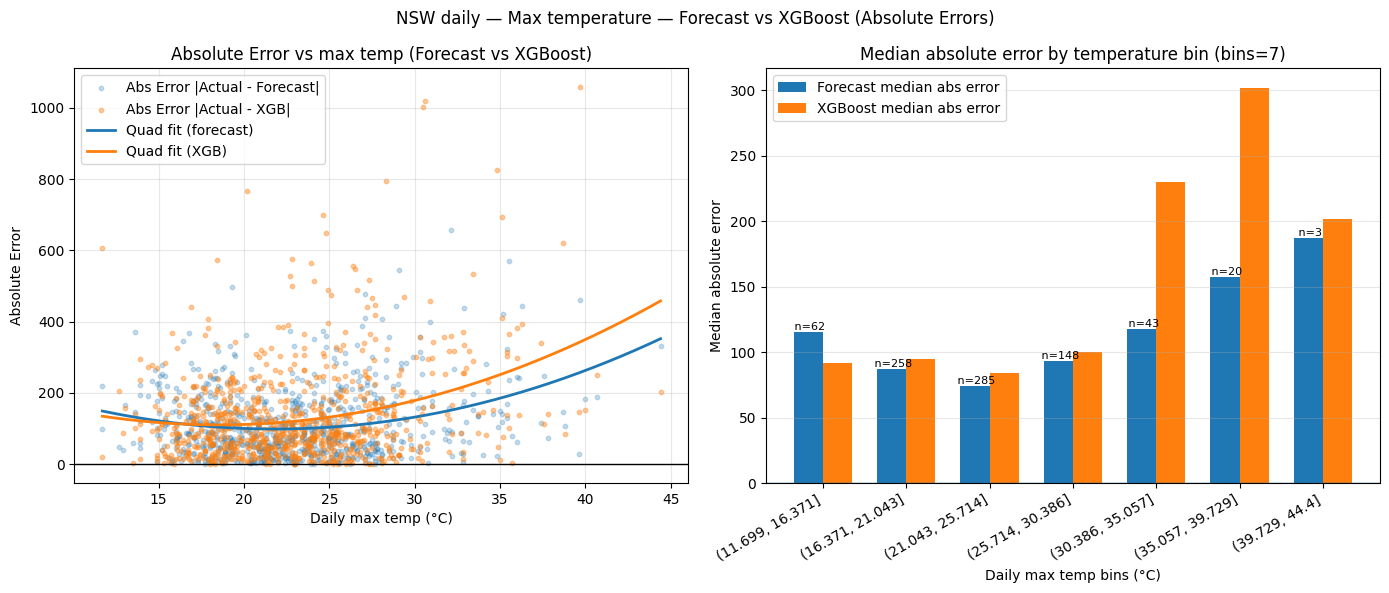


Min Temperature Analysis (XGBoost):


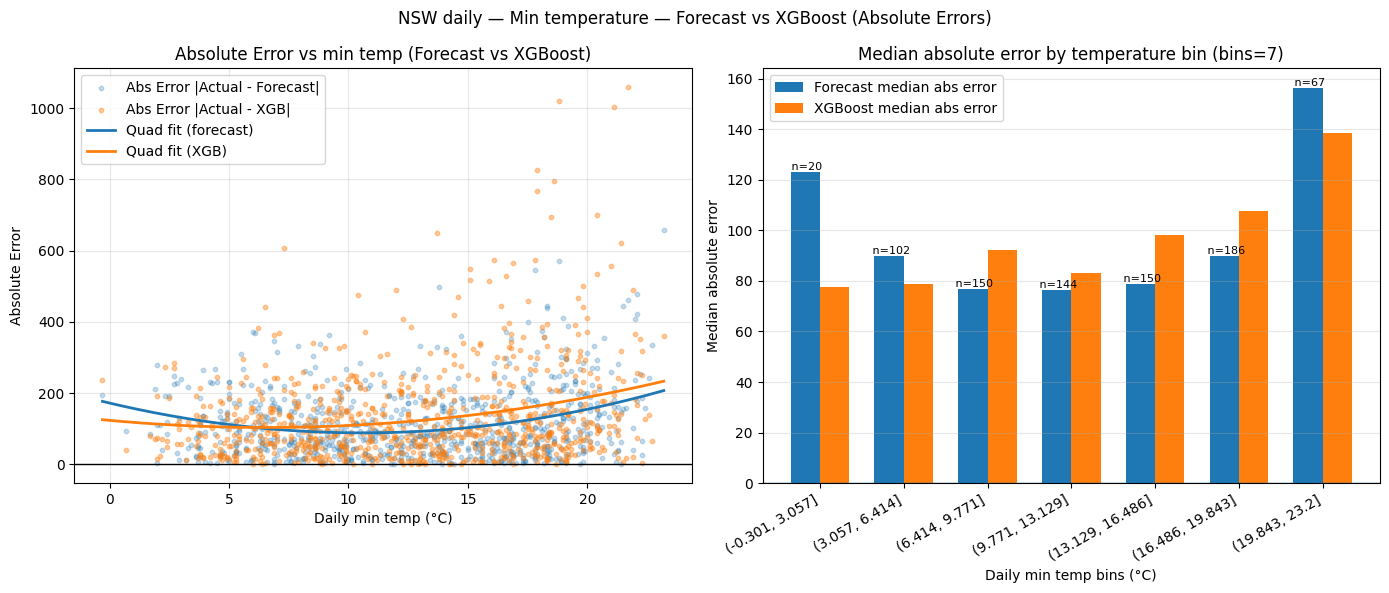


Improvement by temperature extremes (XGBoost):
Hot days (max >35°C): {'n': 23, 'forecast_MAE': 220.23157562684176, 'forecast_R2': 0.8865623994930916, 'xgb_MAE': 292.4603385416669, 'xgb_R2': 0.7669469718436492, 'MAE_reduction': -72.22876291482513, 'R2_improvement': -0.11961542764944233}
Cold days (min <5°C): {'n': 65, 'forecast_MAE': 108.89350348542838, 'forecast_R2': 0.9571127014712028, 'xgb_MAE': 94.52256470352559, 'xgb_R2': 0.9669341276827682, 'MAE_reduction': 14.370938781902794, 'R2_improvement': 0.009821426211565454}
Normal days: {'n': 731, 'forecast_MAE': 109.53627757824971, 'forecast_R2': 0.9650931294670616, 'xgb_MAE': 132.94589757469123, 'xgb_R2': 0.9408065341454231, 'MAE_reduction': -23.40961999644152, 'R2_improvement': -0.02428659532163846}

Original Model (Forecast) Accuracy:
Forecast MSE: 21588.61
Forecast R2: 0.9668

XGBoost Model Accuracy:
XGBoost MSE: 35956.85
XGBoost R2: 0.9448


In [6]:
# Predict
pred_train = best_model.predict(X_train)
pred_test  = best_model.predict(X_test)
pred_all   = best_model.predict(X)

print("Best Params:", random_search.best_params_)
print('-----------------------------------')

print("XGBoost Model - MSE:", mean_squared_error(y_test, pred_test))
print("XGBoost Model - R2:", r2_score(y_test, pred_test))  
print('-----------------------------------')


# Attach predictions and residuals to a DataFrame for analysis
results_df = X_test.copy()
results_df['ACTUAL'] = y_test
results_df['PRED_XGB'] = pred_test
# Make sure the index alignment is correct and the forecast series matches the test set
forecast_test = df_daily['FORECASTDEMAND']['mean'].reindex(X_test.index)
results_df['FORECAST'] = forecast_test.values  # Add forecast as a baseline
results_df['RESID_FORECAST'] = results_df['ACTUAL'] - results_df['FORECAST']
results_df['RESID_XGB'] = results_df['ACTUAL'] - results_df['PRED_XGB']

# Metrics
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    # R-squared
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    metrics = {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape, "R2":r2}
    return metrics
metrics_forecast_test = metrics(y_test, results_df["FORECAST"])
metrics_xgb_test = metrics(y_test, pred_test)
# Print metrics, ensuring no np.float types in output
def to_builtin_type(obj):
    if isinstance(obj, dict):
        return {k: to_builtin_type(v) for k, v in obj.items()}
    elif isinstance(obj, (np.generic, np.ndarray)):
        return obj.item() if hasattr(obj, 'item') else obj.tolist()
    else:
        return obj

# Print metrics for forecast and XGBoost
print("Forecast on test:", to_builtin_type(metrics_forecast_test))
print("XGBoost on test:", to_builtin_type(metrics_xgb_test))

# Calculate improvement
mae_improvement = metrics_forecast_test["MAE"] - metrics_xgb_test["MAE"]
rmse_improvement = metrics_forecast_test["RMSE"] - metrics_xgb_test["RMSE"]
r2_improvement = metrics_xgb_test["R2"] - metrics_forecast_test["R2"]
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/metrics_forecast_test['MAE']*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/metrics_forecast_test['RMSE']*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/metrics_forecast_test['R2']*100:.1f}%)")

def plot_compare_xgb_max_temp(dframe, bins=7):
    dd = dframe.dropna(subset=['temp_max', 'RESID_XGB', 'RESID_FORECAST']).copy()
    if dd.empty:
        print("No data")
        return

    x = dd['temp_max'].to_numpy()
    e_xgb = np.abs(dd['RESID_XGB'].to_numpy())
    e_fc = np.abs(dd['RESID_FORECAST'].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    xg_fc, e_fit_fc = quad_fit(x, e_fc)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Abs Error |Actual - Forecast|", color="C0")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Abs Error |Actual - XGB|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C1", label="Quad fit (XGB)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error")
    axs[0].set_title("Absolute Error vs max temp (Forecast vs XGBoost)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd['temp_max'].min(), dd['temp_max'].max(), bins+1)
    dd = dd.assign(
        TEMP_BIN=pd.cut(dd['temp_max'], bins=edges, include_lowest=True),
        ABS_RESID_XGB=np.abs(dd['RESID_XGB']),
        ABS_RESID_FORECAST=np.abs(dd['RESID_FORECAST'])
    )
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_fc=("ABS_RESID_FORECAST","median"),
        count=("ABS_RESID_FORECAST","size")
    ).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_xgb=("ABS_RESID_XGB","median")
    ).reset_index()
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median abs error", color="C0")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGBoost median abs error", color="C1")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle("NSW daily — Max temperature — Forecast vs XGBoost (Absolute Errors)")
    plt.tight_layout(); plt.show()
def plot_compare_xgb_min_temp(dframe, bins=7):
    dd = dframe.dropna(subset=['temp_min', 'RESID_XGB', 'RESID_FORECAST']).copy()
    if dd.empty:
        print("No data")
        return

    x = dd['temp_min'].to_numpy()
    e_xgb = np.abs(dd['RESID_XGB'].to_numpy())
    e_fc = np.abs(dd['RESID_FORECAST'].to_numpy())

    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)

    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    xg_fc, e_fit_fc = quad_fit(x, e_fc)

    fig, axs = plt.subplots(1,2, figsize=(14,6))
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Abs Error |Actual - Forecast|", color="C0")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Abs Error |Actual - XGB|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C1", label="Quad fit (XGB)")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error")
    axs[0].set_title("Absolute Error vs min temp (Forecast vs XGBoost)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)

    edges = np.linspace(dd['temp_min'].min(), dd['temp_min'].max(), bins+1)
    dd = dd.assign(
        TEMP_BIN=pd.cut(dd['temp_min'], bins=edges, include_lowest=True),
        ABS_RESID_XGB=np.abs(dd['RESID_XGB']),
        ABS_RESID_FORECAST=np.abs(dd['RESID_FORECAST'])
    )
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_fc=("ABS_RESID_FORECAST","median"),
        count=("ABS_RESID_FORECAST","size")
    ).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(
        med_err_xgb=("ABS_RESID_XGB","median")
    ).reset_index()
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median abs error", color="C0")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGBoost median abs error", color="C1")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)

    plt.suptitle("NSW daily — Min temperature — Forecast vs XGBoost (Absolute Errors)")
    plt.tight_layout(); plt.show()
def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["is_extreme_hot"] == 1] # Max temp > 35°C
    cold = dframe.loc[dframe["is_extreme_cold"] == 1] # Min temp < 5°C
    normal = dframe.loc[(dframe["is_extreme_hot"] == 0) & (dframe["is_extreme_cold"] == 0)]
    
    def comp(sub, label):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL"].values, sub["FORECAST"].values)
        xgb = metrics(sub["ACTUAL"].values, sub["PRED_XGB"].values)
        return {label: {"n":len(sub), "forecast_MAE":fc["MAE"], "forecast_R2":fc["R2"],
                "xgb_MAE":xgb["MAE"], "xgb_R2":xgb["R2"],
                "MAE_reduction": fc["MAE"]-xgb["MAE"], "R2_improvement": xgb["R2"]-fc["R2"]}}

    print("\nImprovement by temperature extremes (XGBoost):")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    for key, values in result.items():
        clean_values = {k: float(v) if isinstance(v, np.generic) else v for k, v in values.items()}
        print(f"{key}: {clean_values}")

    # Compare to original model (forecast) accuracy
    print("\nOriginal Model (Forecast) Accuracy:")
    mse_forecast = mean_squared_error(dframe['ACTUAL'], dframe['FORECAST'])
    r2_forecast = r2_score(dframe['ACTUAL'], dframe['FORECAST'])
    print(f"Forecast MSE: {mse_forecast:.2f}")
    print(f"Forecast R2: {r2_forecast:.4f}")

    print("\nXGBoost Model Accuracy:")
    mse_xgb = mean_squared_error(dframe['ACTUAL'], dframe['PRED_XGB'])
    r2_xgb = r2_score(dframe['ACTUAL'], dframe['PRED_XGB'])
    print(f"XGBoost MSE: {mse_xgb:.2f}")
    print(f"XGBoost R2: {r2_xgb:.4f}")

print("Max Temperature Analysis (XGBoost):")
plot_compare_xgb_max_temp(results_df)
print("\nMin Temperature Analysis (XGBoost):")
plot_compare_xgb_min_temp(results_df)
improvement_by_temp_extremes(results_df)

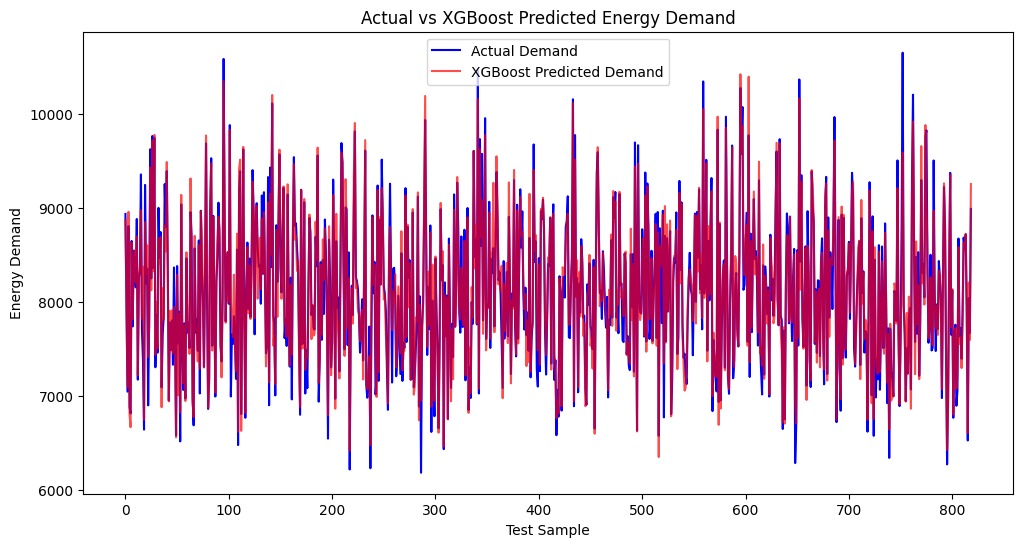

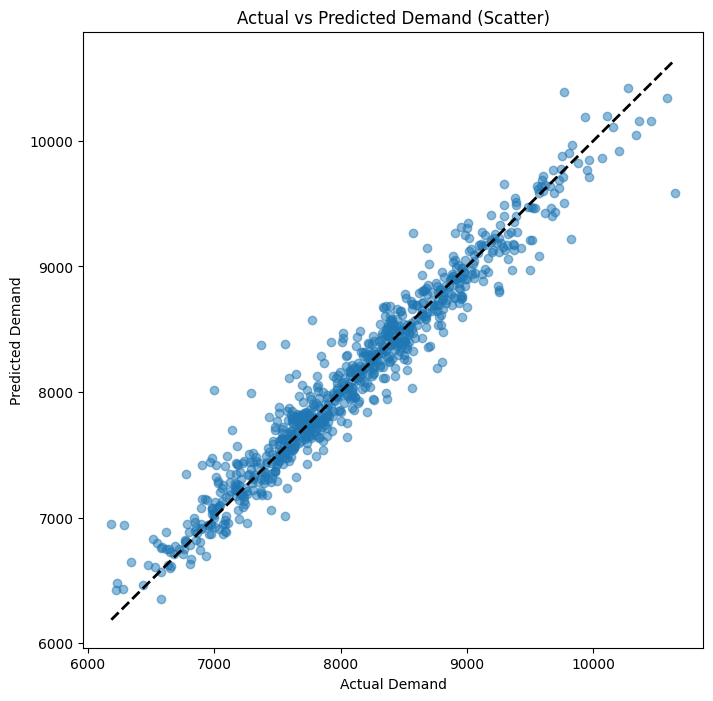

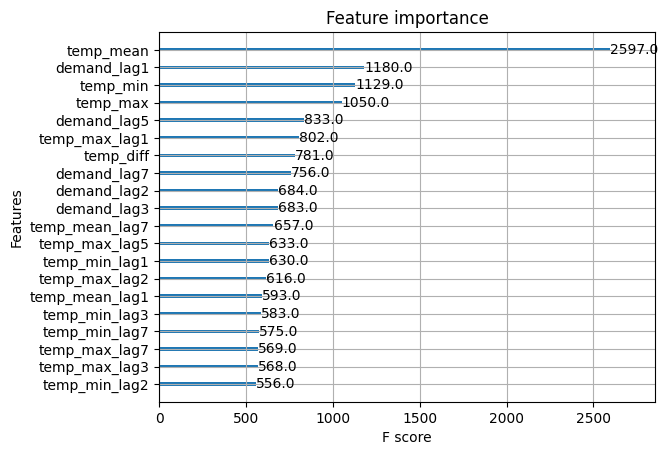

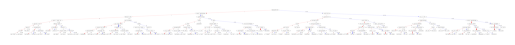

In [7]:
# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Demand', color='blue')
plt.plot(pred_test, label='XGBoost Predicted Demand', color='red', alpha=0.7)
plt.title('Actual vs XGBoost Predicted Energy Demand')
plt.xlabel('Test Sample')
plt.ylabel('Energy Demand')
plt.legend()
plt.show()

# Scatter plot of actual vs predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()

# Feature importance plot
xgb.plot_importance(best_model, max_num_features=20)
# Tree plot with higher resolution
xgb.plot_tree(best_model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=1200, bbox_inches='tight')
